# Seaborn 데이터 시각화 입문

**Seaborn**은 Matplotlib을 기반으로 한 Python 데이터 시각화 라이브러리입니다.

## Seaborn vs Matplotlib

| 특징 | Matplotlib | Seaborn |
|------|-----------|---------|
| **복잡도** | 세밀한 커스터마이징 가능 | 간결한 코드로 통계 그래프 생성 |
| **스타일** | 기본 스타일, 직접 설정 필요 | 미리 정의된 미려한 테마 제공 |
| **데이터 타입** | NumPy 배열 중심 | Pandas DataFrame과 완벽 통합 |
| **통계 기능** | 기본적 | 내장 통계 추정 및 신뢰구간 제공 |

## Seaborn의 주요 특징
1. **Pandas DataFrame**과 원활하게 작동
2. **통계적 데이터 시각화** (분포, 회귀, 범주형 데이터 등)
3. **자동 스타일링** - 색상 팔레트, 테마 자동 적용
4. **다중 변수 시각화** - hue, col, row 파라미터로 쉬운 패싯 그래프 생성

## 설치 방법
```bash
# conda 사용 시
conda install seaborn

# pip 사용 시
pip install seaborn
```

In [ ]:
# conda install seaborn

## 1. 라이브러리 임포트

Seaborn을 사용하기 위해 필요한 라이브러리들을 임포트합니다.

### 주요 라이브러리
- **seaborn (sns)**: 주 시각화 라이브러리, 통계적 그래프 생성
- **matplotlib.pyplot (plt)**: 그래프 출력 및 세부 조정, 한글 폰트 설정
- **pandas (pd)**: 데이터 처리 및 DataFrame 생성

### 별칭(Alias) 사용
- `sns`: seaborn의 공식 별칭 (통계학자 Sam Norman Seaborn의 이름에서 유래)
- `plt`: matplotlib.pyplot의 표준 별칭
- `pd`: pandas의 표준 별칭

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 2. 한글 폰트 설정

Seaborn은 Matplotlib을 기반으로 하므로, 한글 표시를 위해 동일한 폰트 설정이 필요합니다.

### 설정 방법
```python
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지
```

### 운영체제별 권장 폰트
- **Windows**: 'Malgun Gothic', 'NanumGothic'
- **macOS**: 'AppleGothic', 'NanumGothic'
- **Linux**: 'NanumGothic'

### 주의사항
- 한글 폰트 설정은 **모든 그래프에 전역적으로** 적용됨
- 설정 후에는 그래프마다 반복 설정 불필요

In [2]:
# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 3. Seaborn 내장 데이터셋

Seaborn은 학습과 실습을 위해 다양한 **내장 데이터셋**을 제공합니다.

### 데이터셋 목록 확인
`sns.get_dataset_names()` 함수로 사용 가능한 모든 데이터셋을 확인할 수 있습니다.

### 인기 데이터셋 소개
| 데이터셋 | 설명 | 주요 변수 | 활용 예시 |
|---------|------|----------|----------|
| **tips** | 레스토랑 팁 데이터 | total_bill, tip, sex, smoker, day, time, size | 회귀분석, 범주형 시각화 |
| **iris** | 붓꽃 데이터 | sepal_length, sepal_width, petal_length, petal_width, species | 분류, 산점도 |
| **penguins** | 펭귄 데이터 | bill_length, flipper_length, body_mass, species, island | 다변량 분석 |
| **flights** | 항공 승객 데이터 | year, month, passengers | 시계열, 히트맵 |
| **titanic** | 타이타닉 생존 데이터 | survived, pclass, sex, age, fare | 분류, 생존 분석 |

### 코드 설명
- `sns.get_dataset_names()`: 내장 데이터셋 이름 리스트 반환
- `enumerate(dataset_names, 1)`: 1부터 시작하는 번호와 함께 순회

In [3]:
dataset_names = sns.get_dataset_names()

for i, name in enumerate(dataset_names, 1):
    print(f"  {i:2d}. {name}")

   1. anagrams
   2. anscombe
   3. attention
   4. brain_networks
   5. car_crashes
   6. diamonds
   7. dots
   8. dowjones
   9. exercise
  10. flights
  11. fmri
  12. geyser
  13. glue
  14. healthexp
  15. iris
  16. mpg
  17. penguins
  18. planets
  19. seaice
  20. taxis
  21. tips
  22. titanic


### 데이터셋 로드 및 기본 정보 확인

#### 코드 설명
```python
df_tips = sns.load_dataset("tips")  # "tips" 데이터셋을 pandas DataFrame으로 로드
print(df_tips.shape)                 # 데이터의 형태 확인 (행 수, 열 수)
```

#### Tips 데이터셋 개요
- **목적**: 레스토랑에서 지불된 총 금액과 팁 금액의 관계 분석
- **샘플 수**: 244개의 주문 기록
- **변수 수**: 7개

#### load_dataset() 함수 특징
- 온라인에서 데이터를 자동 다운로드 (캐시에 저장)
- 반환 타입: pandas DataFrame
- 범주형 변수는 자동으로 category dtype으로 변환

In [4]:
df_tips = sns.load_dataset("tips")
print(df_tips.shape)

(244, 7)


### 데이터 타입 확인

`df.dtypes` 속성을 통해 각 열의 데이터 타입을 확인합니다.

#### Seaborn의 특별한 처리
Seaborn은 문자열 데이터를 **category 타입**으로 자동 변환합니다.

| 타입 | 설명 | 예시 |
|-----|------|------|
| **float64** | 실수형 | total_bill, tip |
| **int64** | 정수형 | size (인원수) |
| **category** | 범주형 | sex, smoker, day, time |

#### category 타입의 장점
1. **메모리 효율성**: 반복되는 문자열을 정수로 인코딩하여 저장
2. **순서 지정 가능**: 명목형(순서 없음) vs 서열형(순서 있음)
3. **시각화 자동 처리**: 범례, 색상 등이 자동으로 최적화

In [5]:
df_tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

### Category 타입 상세 다루기

#### .cat 접근자 (Accessor)
category 타입의 DataFrame 열은 `.cat` 접근자를 통해 범주 관련 속성과 메서드에 접근할 수 있습니다.

#### 주요 속성
- `.cat.categories`: 범주 목록 반환 (Index 객체)
- `.cat.codes`: 각 값의 범주 인덱스 (정수로 인코딩된 값)
- `.cat.ordered`: 순서형 범주 여부 (True/False)

#### 코드 설명
```python
print(df_tips["smoker"].dtype)           # category 타입 확인
print(df_tips["smoker"].cat.categories)  # ['Yes', 'No'] 범주 목록
```

#### 실무 활용
- 범주 순서 변경 (예: ['No', 'Yes'] → ['Yes', 'No'])
- 새로운 범주 추가/제거
- 범주명 변경 (rename)

In [6]:
# category 타입
print(df_tips["smoker"].dtype)              # category
print(df_tips["smoker"].cat.categories)     # Index(['Yes', 'No'])
# .cat은 category accessor(접근자)

category
Index(['Yes', 'No'], dtype='str')


### CategoricalDtype으로 순서형 범주 만들기

#### 개념
순서형(Ordinal) 범주는 크기나 순서가 있는 범주를 의미합니다.
예: S < M < L < XL (의류 사이즈), 학년 (1학년 < 2학년 < 3학년)

#### CategoricalDtype 클래스
```python
from pandas import CategoricalDtype

size_type = CategoricalDtype(
    categories=["S", "M", "L", "XL"],  # 허용되는 범주 목록
    ordered=True                           # 순서형 여부
)
```

#### 매개변수 설명
- **categories**: 범주의 순서를 지정하는 리스트
- **ordered**: 순서형 여부 (True: 비교 연산 가능, False: 명목형)

#### 순서형 범주의 특징
- 비교 연산 가능: `df["size"] > "M"` → S, M은 False, L, XL은 True
- 정렬 시 지정된 순서대로 정렬됨
- 시각화에서 자동으로 순서가 반영됨

In [7]:
from pandas import CategoricalDtype

size_type = CategoricalDtype(categories=["S", "M", "L", "XL"], ordered=True)
# ordered=True → S < M < L < XL

df = pd.DataFrame({"size": ["M", "XL", "S", "L"]})
df["size"] = df["size"].astype(size_type)

print(df["size"].cat.categories)  # Index(['S', 'M', 'L', 'XL'])
print(df["size"].cat.ordered)     # True

# ordered=True면 비교 연산도 가능
df["size"] > "M"  # S, M은 False

Index(['S', 'M', 'L', 'XL'], dtype='str')
True


0    False
1     True
2    False
3     True
Name: size, dtype: bool

### Category 타입의 데이터 검증

#### 데이터 무결성 보장
CategoricalDtype은 정의되지 않은 범주 값을 자동으로 **NaN (결측값)**으로 처리합니다.

#### 코드 동작 설명
```python
df = pd.DataFrame({"size": ["M", "XL", "S", "XXL"]})  # "XXL"은 정의되지 않음
df["size"] = df["size"].astype(size_type)
# 결과: "XXL"은 NaN으로 변환됨
```

#### 활용 예시
- 데이터 입력 오류 자동 감지
- 설문조사 응답값 검증
- 표준화된 범주값 강제 적용

#### 출력 정보 해석
`Categories (4, object): ['S' < 'M' < 'L' < 'XL']`
- 4개의 범주가 있음
- object 타입
- 순서: S < M < L < XL

In [8]:
# size_type에 정의된 "S", "M", "L", "XL" 외의 값을 넣으면 NaN으로 처리
df = pd.DataFrame({"size": ["M", "XL", "S", "XXL"]})  # "XXL"은 정의 안 됨
df["size"] = df["size"].astype(size_type)

print(df["size"])

# 출력에서
# Categories (4, object): ['S' < 'M' < 'L' < 'XL']는
# 어떤 category인지 보여주는 역할: 4개의 categories, 타입은 object, category 값은 정렬되어 있음

0      M
1     XL
2      S
3    NaN
Name: size, dtype: category
Categories (4, str): ['S' < 'M' < 'L' < 'XL']


C:\Users\nx\AppData\Local\Temp\ipykernel_31072\3035929229.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df["size"] = df["size"].astype(size_type)


## 4. Seaborn 시각화 함수 분류

Seaborn은 데이터 특성과 분석 목적에 따라 다양한 시각화 함수를 제공합니다.

### 1. 분포 시각화 (Distribution)
| 함수 | 설명 | 특징 |
|-----|------|------|
| **histplot** | 히스토그램 | 데이터 분포를 구간별 막대로 표현 |
| **kdeplot** | 커널 밀도 추정 | 연속적인 밀도 곡선으로 분포 표현 |
| **ecdfplot** | 누적 분포 함수 | 누적 비율로 분포 표현 |
| **rugplot** | 러그 플롯 | 데이터 포인트를 축에 직선으로 표시 |
| **displot** | 분포 플롯 (통합) | 위 함수들을 통합, FacetGrid 지원 |

### 2. 관계형 시각화 (Relational)
| 함수 | 설명 | 특징 |
|-----|------|------|
| **scatterplot** | 산점도 | 두 변수 간 관계 시각화 |
| **lineplot** | 선 그래프 | 시간/순서에 따른 변화 표현 |
| **relplot** | 관계 플롯 (통합) | scatter/line 선택, FacetGrid 지원 |

### 3. 범주형 시각화 (Categorical)
| 함수 | 설명 | 특징 |
|-----|------|------|
| **barplot** | 막대 그래프 | 평균값에 신뢰구간 표시 |
| **countplot** | 카운트 플롯 | 범주별 빈도 수 표시 |
| **boxplot** | 박스플롯 | 사분위수, 이상치 표시 |
| **violinplot** | 바이올린 플롯 | 분포 형태를 곡선으로 표현 |
| **stripplot** | 스트립 플롯 | 개별 데이터 포인트 표시 |
| **swarmplot** | 스웜 플롯 | 겹치지 않는 점 배열 |
| **catplot** | 범주 플롯 (통합) | 위 함수들 통합, FacetGrid 지원 |

### 4. 회귀 시각화 (Regression)
| 함수 | 설명 |
|-----|------|
| **regplot** | 회귀선이 포함된 산점도 |
| **lmplot** | 회귀 플롯 (FacetGrid 지원) |
| **residplot** | 잔차 플롯 |

### 5. 행렬 시각화 (Matrix)
| 함수 | 설명 |
|-----|------|
| **heatmap** | 히트맵 (상관관계, 빈도 등) |
| **clustermap** | 계층적 군집화가 적용된 히트맵 |

### 6. 다변량 시각화 (Multivariate)
| 함수 | 설명 |
|-----|------|
| **pairplot** | 변수 쌍별 산점도 행렬 |
| **jointplot** | 두 변수의 관계와 주변 분포 동시 표시 |
| **PairGrid** | pairplot의 저수준 인터페이스 |
| **FacetGrid** | 다중 서브플롯 생성 도구 |

In [ ]:
# 분포(Distribution) — histplot, kdeplot, ecdfplot, rugplot, displot
# 관계형(Relational) — scatterplot, lineplot, relplot
# 범주형(Categorical) — barplot, countplot, boxplot, violinplot, stripplot, swarmplot, pointplot, catplot
# 회귀(Regression) — regplot, lmplot, residplot
# 행렬(Matrix) — heatmap, clustermap
# 다변량(Multivariate) — pairplot, PairGrid, FacetGrid, jointplot

## 5. 분포 시각화: histplot

### histplot이란?
**히스토그램(Histogram)**은 연속형 데이터의 분포를 구간(bin)별 빈도로 표현하는 그래프입니다.

### Seaborn vs Matplotlib
- **Matplotlib**: `plt.hist(data)` - 기본적인 히스토그램
- **Seaborn**: `sns.histplot(data=df, x="column")` - 더 많은 기능과 스타일 옵션

### 코드 설명
```python
sns.histplot(data=df_tips, x="total_bill", bins=20)
```
- **data**: 시각화할 DataFrame 지정
- **x**: x축에 표시할 열 이름
- **bins**: 데이터를 나눌 구간 수 (기본값: "auto")

### bins 매개변수의 중요성
- **bins가 너무 작으면**: 세부 패턴 파악 어려움
- **bins가 너무 크면**: 노이즈가 많아짐
- **적절한 bins 선택**: 데이터 크기와 분포 특성에 따라 조정

In [10]:
df_tips = sns.load_dataset("tips")

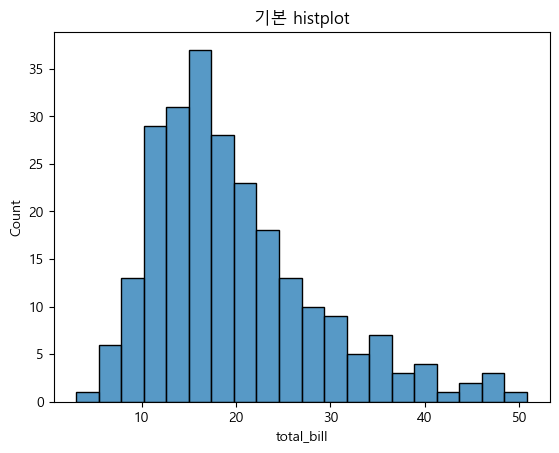

In [11]:
# 분포(Distribution) - histplot

sns.histplot(data=df_tips, x="total_bill", bins=20)
plt.title("기본 histplot")
plt.show()

### KDE (Kernel Density Estimation) 밀도 곡선

#### KDE란?
**커널 밀도 추정(KDE)**은 히스토그램의 계단식 형태를 부드러운 곡선으로 근사하는 방법입니다.

#### 특징
- 히스토그램의 이산적인 bin 대신 **연속적인 분포** 표현
- 데이터의 **전체적인 경향성** 파악에 유용
- bin 수에 덜 민감하여 **안정적인 분포 추정** 제공

#### 코드 설명
```python
sns.histplot(data=df_tips, x="total_bill", bins=20, kde=True)
```
- **kde=True**: KDE 곡선을 히스토그램 위에 추가
- 곡선 아래 면적의 합은 1 (확률 밀도 함수 특성)

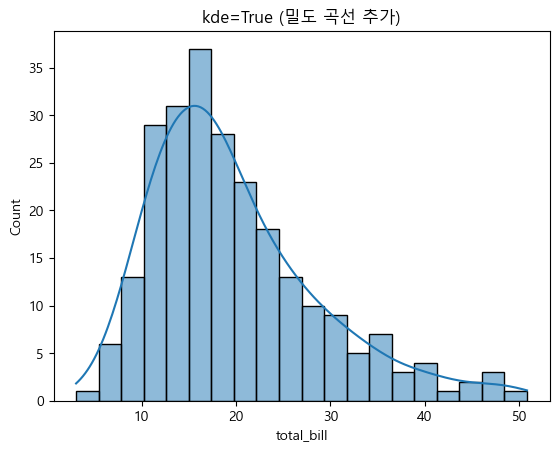

In [9]:
# 분포(Distribution) - histplot

sns.histplot(data=df_tips, x="total_bill", bins=20, kde=True)
plt.title("kde=True (밀도 곡선 추가)")
plt.show()

### hue 매개변수: 범주별 분리 시각화

#### hue란?
**hue**는 데이터를 범주별로 색상을 달리하여 표시하는 매개변수입니다.

#### 코드 설명
```python
sns.histplot(data=df_tips, x="total_bill", hue="sex", multiple="layer")
```
- **hue="sex"**: 성별(Male/Female)에 따라 다른 색상으로 표시
- **multiple="layer"**: 여러 범주를 겹쳐서 표시 (기본값)

#### multiple 매개변수 옵션
| 옵션 | 설명 | 활용 예시 |
|-----|------|----------|
| **"layer"** | 투명도를 적용하여 겹쳐 표시 | 두 분포 비교 |
| **"dodge"** | 나란히 배치하여 표시 | 정확한 수량 비교 |
| **"stack"** | 쌓아 올려 표시 | 전체 대비 비율 |
| **"fill"** | 전체를 100%로 하고 비율 표시 | 상대적 비율 비교 |

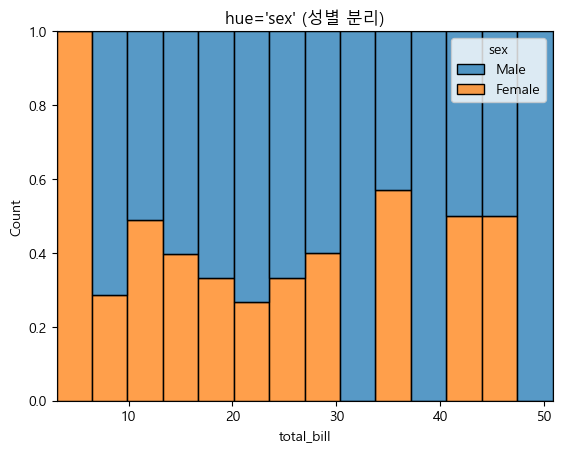

In [19]:
# 분포(Distribution) - histplot

# multiple은 hue 겹침 방식 조정; "layer" (기본, 겹침) / "dodge" (나란히) / "stack" (쌓기) / "fill" (비율)
sns.histplot(data=df_tips, x="total_bill", hue="sex", multiple="fill")
plt.title("hue='sex' (성별 분리)")
plt.show()

### stat 매개변수: y축 기준 변경

#### stat이란?
히스토그램의 **y축 값의 의미**를 변경하는 매개변수입니다.

#### stat 옵션별 비교
| 옵션 | 설명 | 수학적 의미 | 사용 상황 |
|-----|------|-----------|----------|
| **"count"** | 빈도 수 | 각 구간의 데이터 개수 | 기본, 절대적 수량 비교 |
| **"frequency"** | 빈도 | count / bin_width | 구간 크기가 다를 때 |
| **"density"** | 밀도 | 면적의 합 = 1 | 연속형 데이터, KDE와 함께 사용 |
| **"probability"** | 확률 | 막대 높이의 합 = 1 | 이산형 데이터, 상대적 비율 |

#### 코드 설명
```python
sns.histplot(data=df_tips, x="total_bill", stat="density", kde=True)
```
- **stat="density"**: 확률 밀도 함수 형태로 표시
- KDE 곡선과 함께 사용하면 분포의 형태를 명확히 파악 가능

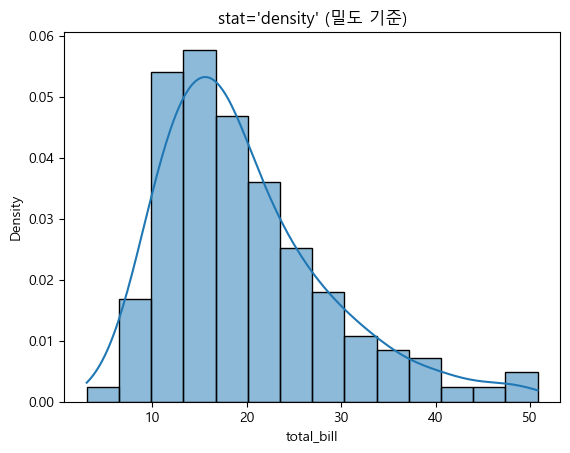

In [ ]:
# 분포(Distribution) - histplot

# stat은 y축 기준 변경; "count" (기본) / "frequency" / "density" / "probability"
#     density: continuous; 전체 면적의 합이 1
# probability:   discrete; 막대 높이의 합이 1
# ※ KDE를 사용하는 경우 density를 선택

# 이건 시험 안나옴

sns.histplot(data=df_tips, x="total_bill", stat="density", kde=True)
plt.title("stat='density' (밀도 기준)")
plt.show()

### 색상 및 투명도 조정

#### 색상 지정
- **color**: matplotlib에서 지원하는 모든 색상명 또는 HEX 코드 사용 가능
- 예: 'coral', 'steelblue', '#FF6B6B'

#### 투명도 (alpha)
- **alpha**: 0~1 사이의 값으로 투명도 조절
- 0: 완전 투명, 1: 완전 불투명
- 겹치는 데이터 표시 시 유용

#### 코드 예시
```python
sns.histplot(data=df_tips, x='total_bill', color='coral', alpha=0.8)
```
- color: 막대 색상을 coral로 지정
- alpha=0.8: 80% 불투명도로 표시

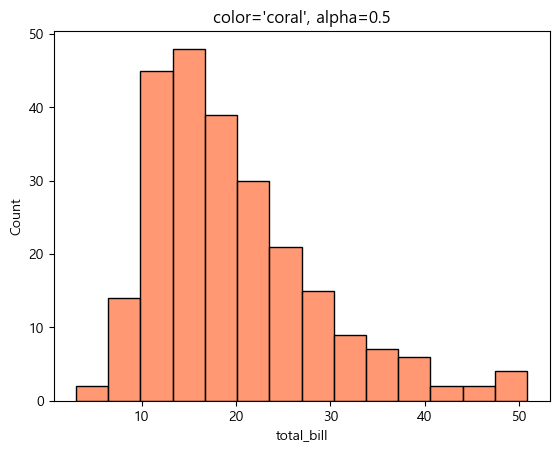

In [21]:
# 분포(Distribution) - histplot

# 색 + 투명도
sns.histplot(data=df_tips, x="total_bill", color="coral", alpha=0.8)
plt.title("color='coral', alpha=0.5")
plt.show()

## 6. 관계형 시각화: scatterplot (산점도)

### Penguins 데이터셋

이 실습에서는 **Palmer Penguins** 데이터셋을 사용합니다. 이 데이터셋은 기계학습 교육에서 유명한 Iris 데이터셋의 현대적인 대안으로 제시된 데이터셋입니다.

#### 데이터셋 소개
- **출처**: Antarctica Palmer Station에서 수집된 3종의 펭귄 관측 데이터
- **샘플 수**: 344마리의 펭귄 관측 기록
- **변수 수**: 7개

#### 주요 컬럼 설명
| 컬럼명 | 설명 | 타입 |
|-------|------|------|
| **species** | 펭귄 종 (Adelie, Chinstrap, Gentoo) | 범주형 |
| **island** | 서식 섬 (Biscoe, Dream, Torgersen) | 범주형 |
| **bill_length_mm** | 부리 길이 (mm) | 연속형 |
| **bill_depth_mm** | 부리 두께/깊이 (mm) | 연속형 |
| **flipper_length_mm** | 날개(지느러미) 길이 (mm) | 연속형 |
| **body_mass_g** | 체중 (g) | 연속형 |
| **sex** | 성별 (Male, Female) | 범주형 |

#### 코드 설명
```python
df_penguins = sns.load_dataset("penguins")
```
- `sns.load_dataset("penguins")`: Seaborn 내장 펭귄 데이터셋을 DataFrame으로 로드
- 이 데이터셋을 사용하여 산점도(scatterplot)의 다양한 기능을 실습합니다.

In [22]:
df_penguins = sns.load_dataset("penguins")
print(df_penguins.shape)
print(df_penguins.dtypes)
# species               펭귄 종 (Adelie, Chinstrap, Gentoo)
# island                서식 섬 (Biscoe, Dream, Torgersen)
# bill_length_mm        부리 길이 (mm)
# bill_depth_mm         부리 두께 (mm)
# flipper_length_mm     날개 길이 (mm)
# body_mass_g           체중 (g)
# sex                   성별 (Male, Female)

(344, 7)
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


### 기본 scatterplot

#### scatterplot이란?
**산점도(Scatter Plot)**는 두 개의 연속형 변수 간의 관계를 시각화하는 가장 기본적인 그래프입니다.

#### 코드 설명
```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm", hue="species")
```

#### 주요 매개변수
- **data**: 시각화할 DataFrame
- **x**: x축 변수 (연속형) - 부리 길이
- **y**: y축 변수 (연속형) - 날개 길이
- **hue**: 색상으로 구분할 범주형 변수 - 펭귄 종

#### hue 매개변수
- 데이터를 특정 범주별로 다른 색상으로 표시합니다.
- 범례(legend)가 자동으로 생성되어 각 색상이 어떤 범주를 의미하는지 표시합니다.
- **언제 사용하나요?**: 그룹별로 데이터를 구분하여 패턴을 비교하고자 할 때

#### 해석 예시
펭귄 종(species)별로 색상이 다르게 표시되므로, 각 종의 부리 길이와 날개 길이 간의 관계를 한눈에 비교할 수 있습니다.

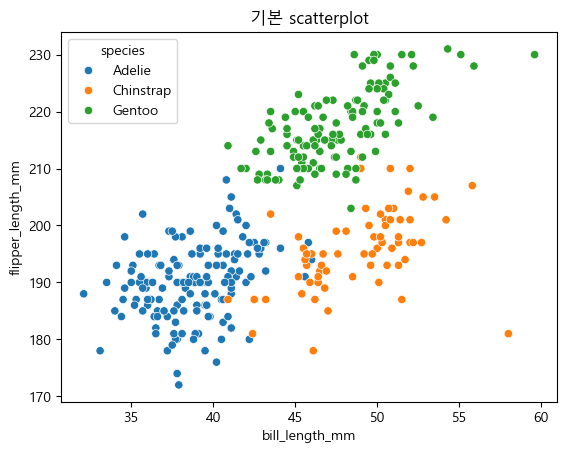

In [23]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm", hue="species")
plt.title("기본 scatterplot")
plt.show()

### style 매개변수: 마커 모양으로 구분

#### style이란?
**style** 매개변수는 데이터를 범주별로 다른 마커(marker) 모양으로 표시합니다.

#### 코드 설명
```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm", style="species")
```

#### 주요 특징
- **hue**가 색상으로 구분한다면, **style**은 점의 모양(○, △, □ 등)으로 구분합니다.
- 각 범주별로 서로 다른 마커 기호가 자동으로 할당됩니다.

#### 언제 사용하나요?
- **흑백 인쇄**가 필요한 경우 (색상이 구분되지 않음)
- 색맹(색을 구분하기 어려운 사람)을 고려한 접근성이 필요할 때
- 색상 외에 추가적인 구분이 필요할 때

#### hue와 style의 차이
| 매개변수 | 구분 방식 | 장점 | 단점 |
|---------|----------|------|------|
| **hue** | 색상 | 직관적, 빠른 인식 | 흑백 인쇄 시 구분 어려움 |
| **style** | 마커 모양 | 흑백에서도 구분 가능 | 범주가 많아지면 구분 어려움 |

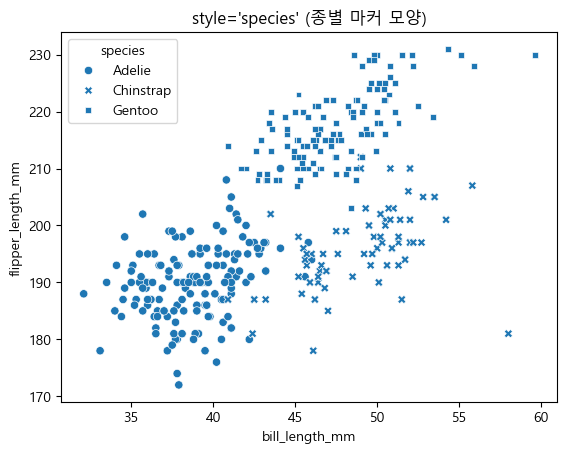

In [24]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm", style="species")
plt.title("style='species' (종별 마커 모양)")
plt.show()

### hue + style 동시 적용: 최대한의 구분력

#### 개념
**hue**와 **style**을 동시에 사용하면 색상과 마커 모양 두 가지 시각적 속성으로 데이터를 구분합니다.

#### 코드 설명
```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="species")
```

#### 효과
- 동일한 변수(species)를 hue와 style에 모두 매핑하면, 각 종마다 고유한 색상과 모양이 동시에 적용됩니다.
- 범례에도 색상과 모양이 함께 표시되어 가독성이 높아집니다.

#### 언제 사용하나요?
- **범주가 많을 때**: 단일 속성(색상만)으로는 구분이 어려운 경우
- **복잡한 그래프**: 여러 요소가 겹쳐 있을 때 이중 구분으로 명확성 확보
- **프레젠테이션 및 출판**: 다양한 매체(컬러/흑백)에서 모두 잘 보이도록

#### 주의사항
- 너무 많은 범주에 style을 적용하면 마커 모양이 고갈되거나 구분이 어려워질 수 있습니다.
- 일반적으로 style은 6~7개 이하의 범주에 적합합니다.

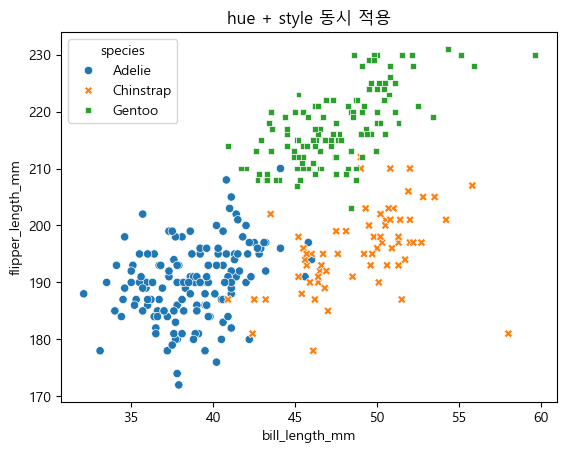

In [25]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="species")
plt.title("hue + style 동시 적용")
plt.show()

### size 매개변수: 버블 차트 효과

#### size란?
**size** 매개변수는 데이터의 값에 따라 점의 크기를 다르게 표시하여, **세 번째 변수**를 시각화합니다.

#### 코드 설명
```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                size="body_mass_g")
```

#### 주요 특징
- **size**: 점의 크기로 표현할 연속형 변수
- 값이 클수록 점이 크게, 값이 작을수록 점이 작게 표시됩니다.
- 자동으로 범례가 생성되어 크기와 값의 대응 관계를 보여줍니다.

#### 언제 사용하나요?
- **다변량 시각화**: 2개 변수(x, y) 외에 제3의 변수를 추가로 표현하고자 할 때
- **버블 차트(Bubble Chart)**: 점 크기로 세 번째 차원을 인코딩
- **상관관계 탐색**: 세 변수 간의 동시 관계 파악

#### 해석 예시
이 예제에서는 체중(body_mass_g)이 큰 펭귄이 큰 점으로 표시됩니다. 이를 통해 부리 길이와 날개 길이뿐만 아니라 체중의 크기까지 한 그래프에서 파악할 수 있습니다.

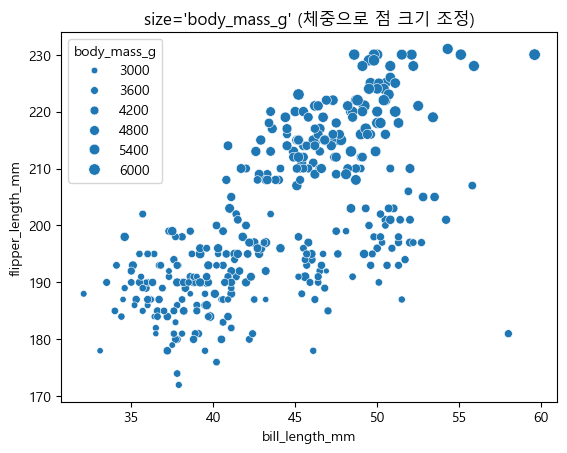

In [26]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                size="body_mass_g")
plt.title("size='body_mass_g' (체중으로 점 크기 조정)")
plt.show()

### hue + style + size: 5차원 데이터 시각화

#### 개념
Seaborn의 scatterplot은 **세 가지 미적 속성(색상, 모양, 크기)**을 동시에 사용하여 다차원 데이터를 시각화할 수 있습니다.

#### 코드 설명
```python
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="island", size="body_mass_g")
```

#### 5가지 데이터 차원
| 차원 | 변수 | 시각적 속성 | 설명 |
|-----|------|-----------|------|
| 1차원 | bill_length_mm | x축 위치 | 부리 길이 |
| 2차원 | flipper_length_mm | y축 위치 | 날개 길이 |
| 3차원 | species | 색상(hue) | 펭귄 종 |
| 4차원 | island | 모양(style) | 서식 섬 |
| 5차원 | body_mass_g | 크기(size) | 체중 |

#### 언제 사용하나요?
- **탐색적 데이터 분석(EDA)**: 여러 변수 간의 복합 관계를 한 번에 탐색
- **데이터 기반 의사결정**: 다양한 속성을 동시에 고려해야 할 때
- **리서치/논문**: 풍부한 정보를 담은 고밀도 시각화가 필요할 때

#### 주의사항
- 너무 많은 정보를 한 번에 담으면 **시각적 복잡도**가 증가하여 해석이 어려워질 수 있습니다.
- **sizes 매개변수**를 사용하여 점 크기 범위를 직접 지정할 수도 있습니다:
  ```python
  sns.scatterplot(..., size="body_mass_g", sizes=(20, 200))
  ```

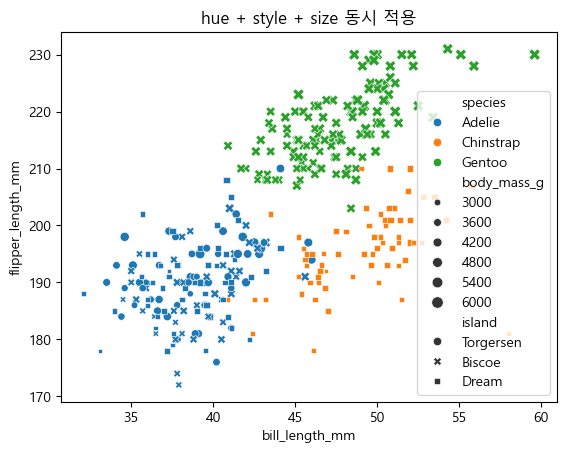

In [27]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="island", size="body_mass_g")
# sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
#                size="body_mass_g", sizes=(20, 200))
# size 범위 직접 지정

plt.title("hue + style + size 동시 적용")
plt.show()

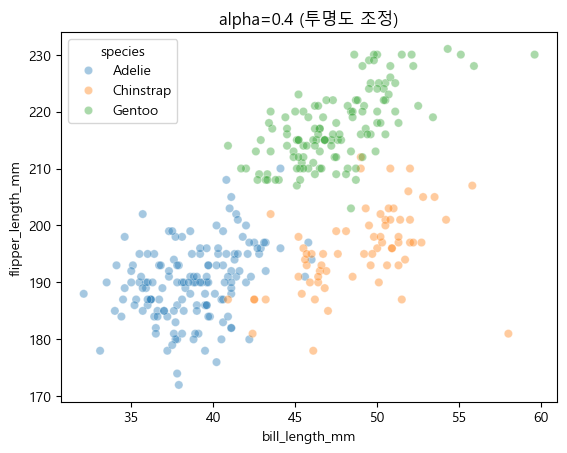

In [28]:
# 관계형(Relational) — scatterplot

sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", alpha=0.4)
plt.title("alpha=0.4 (투명도 조정)")
plt.show()

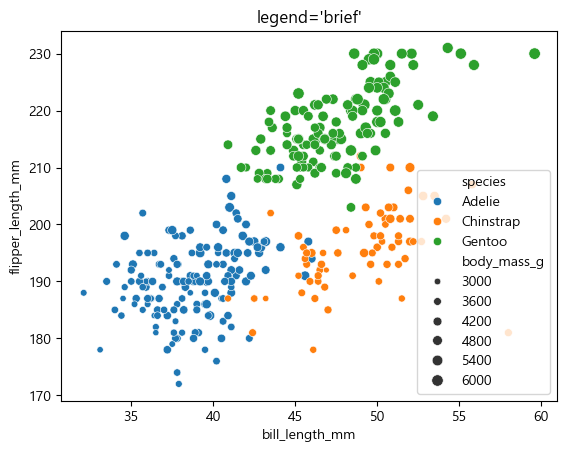

In [29]:
# 관계형(Relational) — scatterplot

# legend: 범례 표기 방식; "auto" (기본) / "brief" / "full" / False
sns.scatterplot(data=df_penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", size="body_mass_g", legend="brief")
plt.title("legend='brief'")
plt.show()

In [30]:
df_flights = sns.load_dataset("flights")
print(df_flights.shape)
print(df_flights.dtypes)
# year          연도 (1949~1960)
# month         월 (Jan~Dec)
# passengers    항공 승객 수

(144, 3)
year             int64
month         category
passengers       int64
dtype: object


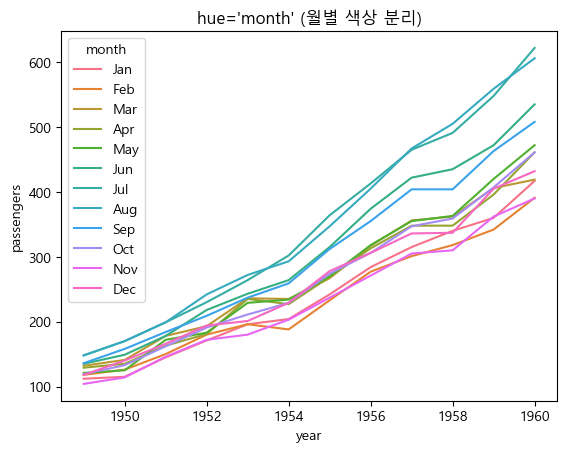

In [31]:
# 관계형(Relational) — lineplot

sns.lineplot(data=df_flights, x="year", y="passengers", hue="month")
plt.title("hue='month' (월별 색상 분리)")
plt.show()

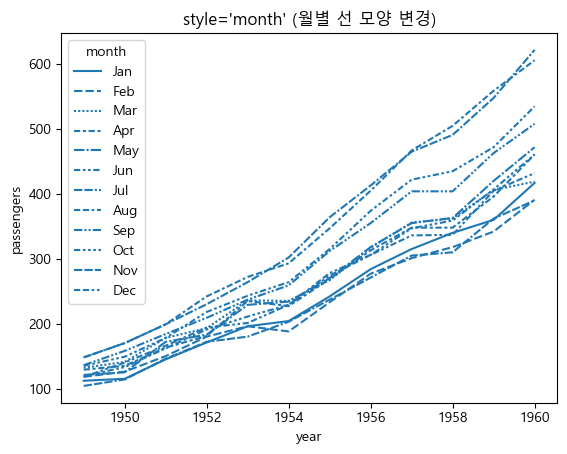

In [32]:
# 관계형(Relational) — lineplot

sns.lineplot(data=df_flights, x="year", y="passengers", style="month")
plt.title("style='month' (월별 선 모양 변경)")
plt.show()

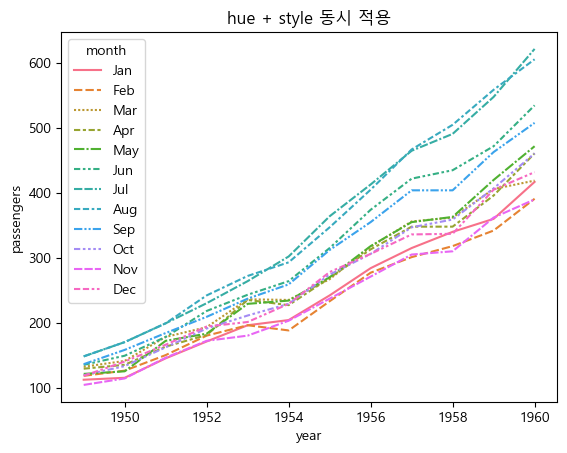

In [33]:
# 관계형(Relational) — lineplot

sns.lineplot(data=df_flights, x="year", y="passengers", hue="month", style="month")
plt.title("hue + style 동시 적용")
plt.show()

In [34]:
df_flights.head()
# year, month의 형태이므로 year는 중복됨 

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


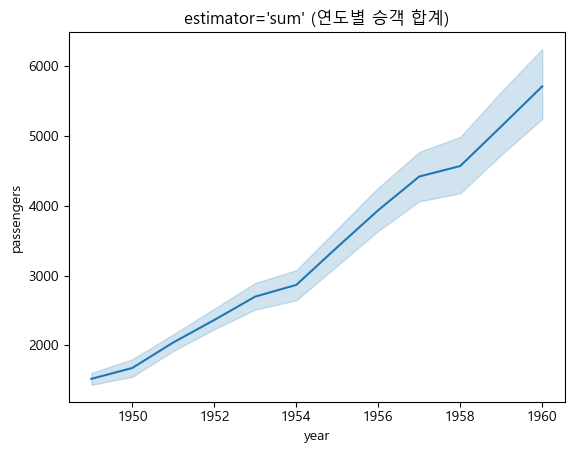

In [35]:
# 관계형(Relational) — lineplot

# year - passengers의 관계
# year 하나에 12개의 passengers가 있는 상태
# estimator는 집계함수 역할; mean, sum, max
sns.lineplot(data=df_flights, x="year", y="passengers", estimator="sum")
plt.title("estimator='sum' (연도별 승객 합계)")
plt.show()

# 기본값은 mean, 신뢰구간(errorbar)도 함께 표시
# 신뢰구간이 크다 → 데이터의 변동이 크다 → 평균의 신뢰도가 떨어진다

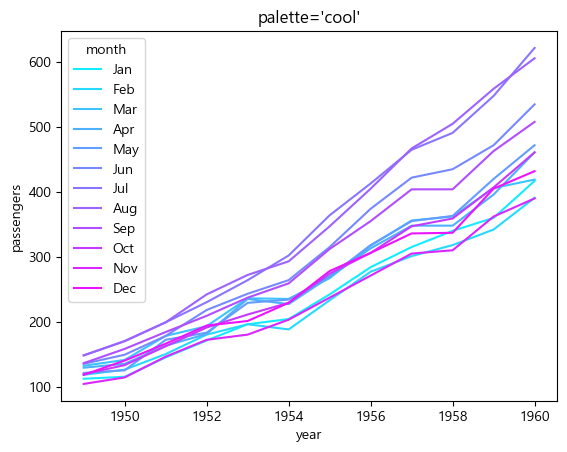

In [36]:
# 관계형(Relational) — lineplot

# 팔레트: 그래프에서 사용하는 "미리 정해놓은" 색 집합
sns.lineplot(data=df_flights, x="year", y="passengers", hue="month", palette="cool")
plt.title("palette='cool'")
plt.show()

In [37]:
# 전체 팔레트 목록 출력
print(plt.colormaps())

# 팔레트의 색 확인
# https://seaborn.pydata.org/tutorial/color_palettes.html

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

In [38]:
df_tips = sns.load_dataset("tips")
df_tips.dtypes
# size는 인원수

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

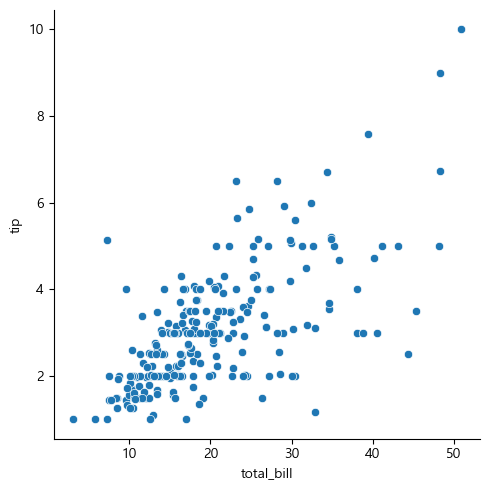

In [39]:
# 관계형(Relational) — relplot

# kind — 그래프 종류 선택
# "scatter" (기본) / "line"
sns.relplot(data=df_tips, x="total_bill", y="tip", kind="scatter")
plt.show()

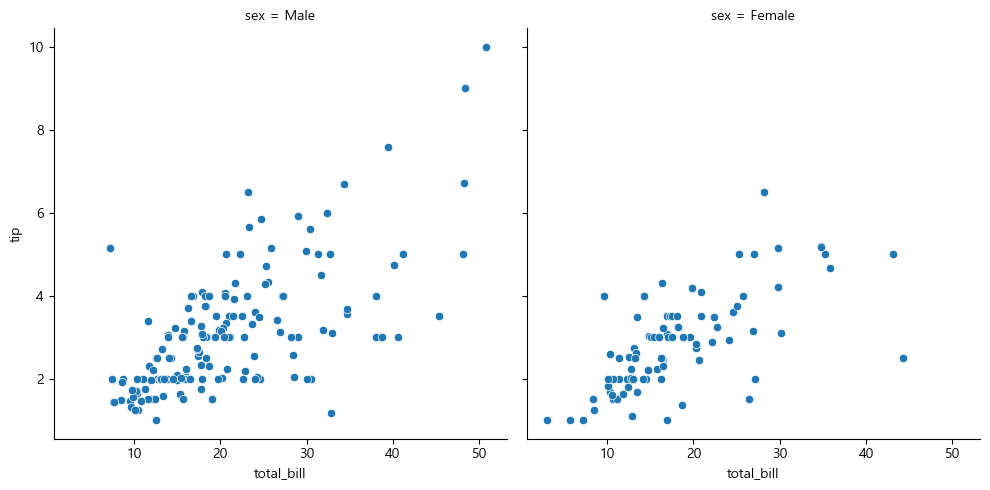

In [40]:
# 관계형(Relational) — relplot

# Facet
sns.relplot(data=df_tips, x="total_bill", y="tip", col="sex")
plt.show()

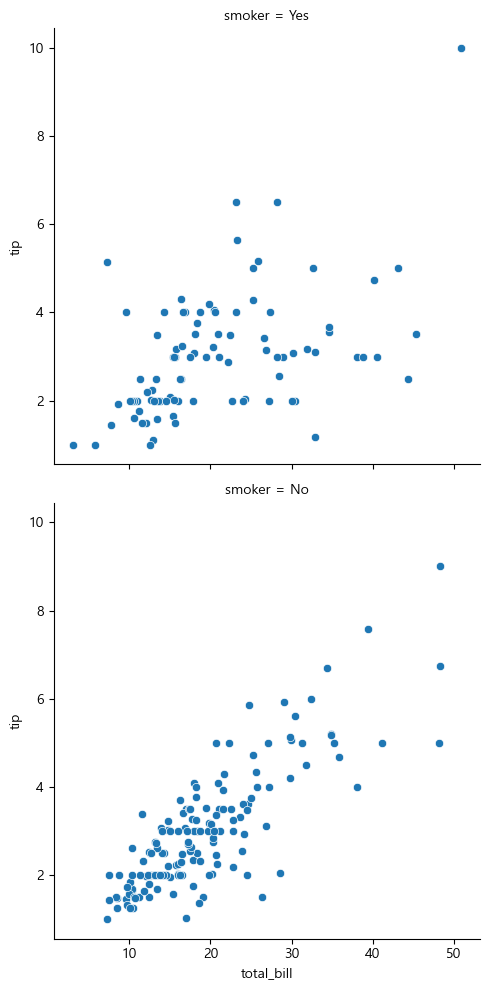

In [41]:
# 관계형(Relational) — relplot

# Facet
sns.relplot(data=df_tips, x="total_bill", y="tip", row="smoker")
plt.show()

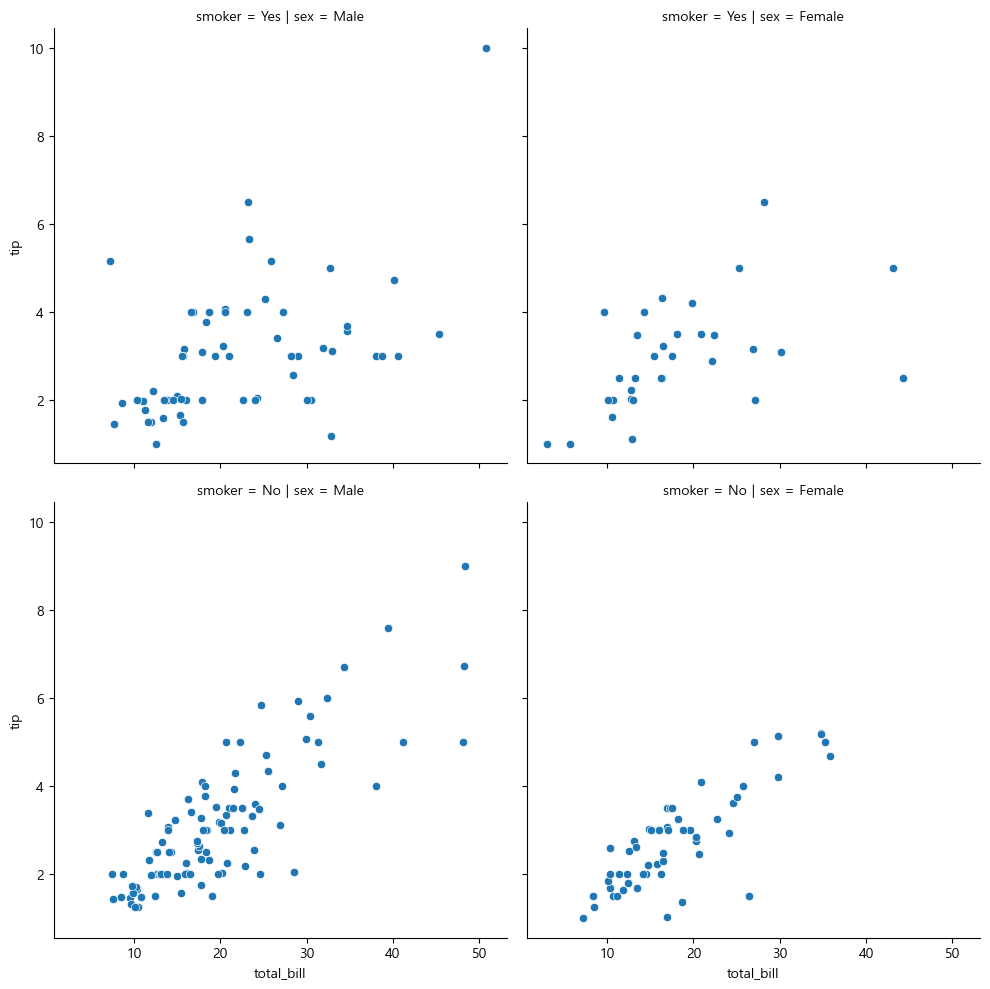

In [42]:
# 관계형(Relational) — relplot

# col + row — 격자 형태 패싯
sns.relplot(data=df_tips, x="total_bill", y="tip", col="sex", row="smoker")
plt.show()

In [ ]:
# 관계형(Relational) — relplot

sns.relplot(data=df_tips, x="total_bill", y="tip", hue="smoker", col="sex")
plt.show()

In [ ]:
# 관계형(Relational) — relplot

# hue + style + size + col 동시 적용
sns.relplot(data=df_tips, x="total_bill", y="tip",
            hue="smoker", style="smoker", size="size", col="sex")
plt.show()